# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [10]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.data import get_contunious_data, get_discrete_data
from python.visualization import plot_fit_quantiles, plot_fit_cdf

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [11]:
# Lade die originale R-Datei
result_rda = pyreadr.read_r('../data/dube.rda')
df_raw = result_rda['dube']

# Spalten passend für DiSCo umbenennen
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

Datensatz geladen: 652870 Zeilen


,time_col,id_col,y_col
0,1998.0,1.0,2.791217
1,1998.0,1.0,0.165951
2,1998.0,1.0,1.674730
3,1998.0,1.0,2.088006
4,1998.0,1.0,3.639715


In [12]:
print("Initialisiere DiSCo mit Dube-Daten...")  
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=100,              # Grid Size
    num_cores=-2,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9,            # Entspricht den Parametern in der Vignette
    CI=True,             # Bootstrap-Konfidenzintervalle berechnen
    cl=0.95,             # Konfidenzniveau für Intervalle
    uniform=False,
    perm=True,
    mixture=False
)

result = disco_model.fit()

Initialisiere DiSCo mit Dube-Daten...


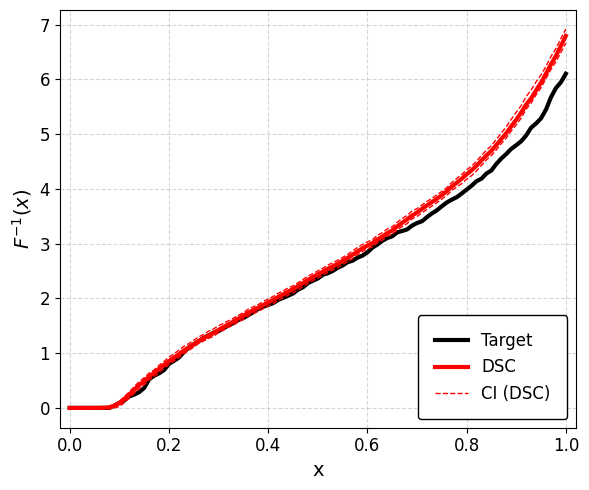

In [13]:
plot_fit_quantiles(result, show_controls=False)

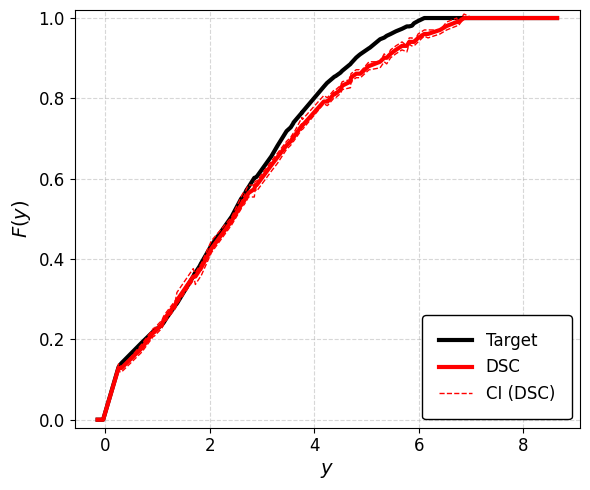

In [14]:
plot_fit_cdf(result, show_controls=False)

In [15]:
pd.Series(result.weights, index=disco_model.controls_id).sort_values(ascending=False).head(5)

39.0    0.154219
29.0    0.145689
45.0    0.092699
51.0    0.065187
26.0    0.064815
dtype: float64


Call:
DiSCoTEA

--- Treatment Effects ---
 Time  X_from  X_to  Quantile Delta  Std. Error   [95%   Conf. Band] Sig
 2003     0.0   0.9         -0.0623      0.0410 -0.1271       0.0421    
 2004     0.0   0.9         -0.1590      0.0457 -0.2531      -0.0827   *

--- Permutation Test ---
p-value: 0.1765

None


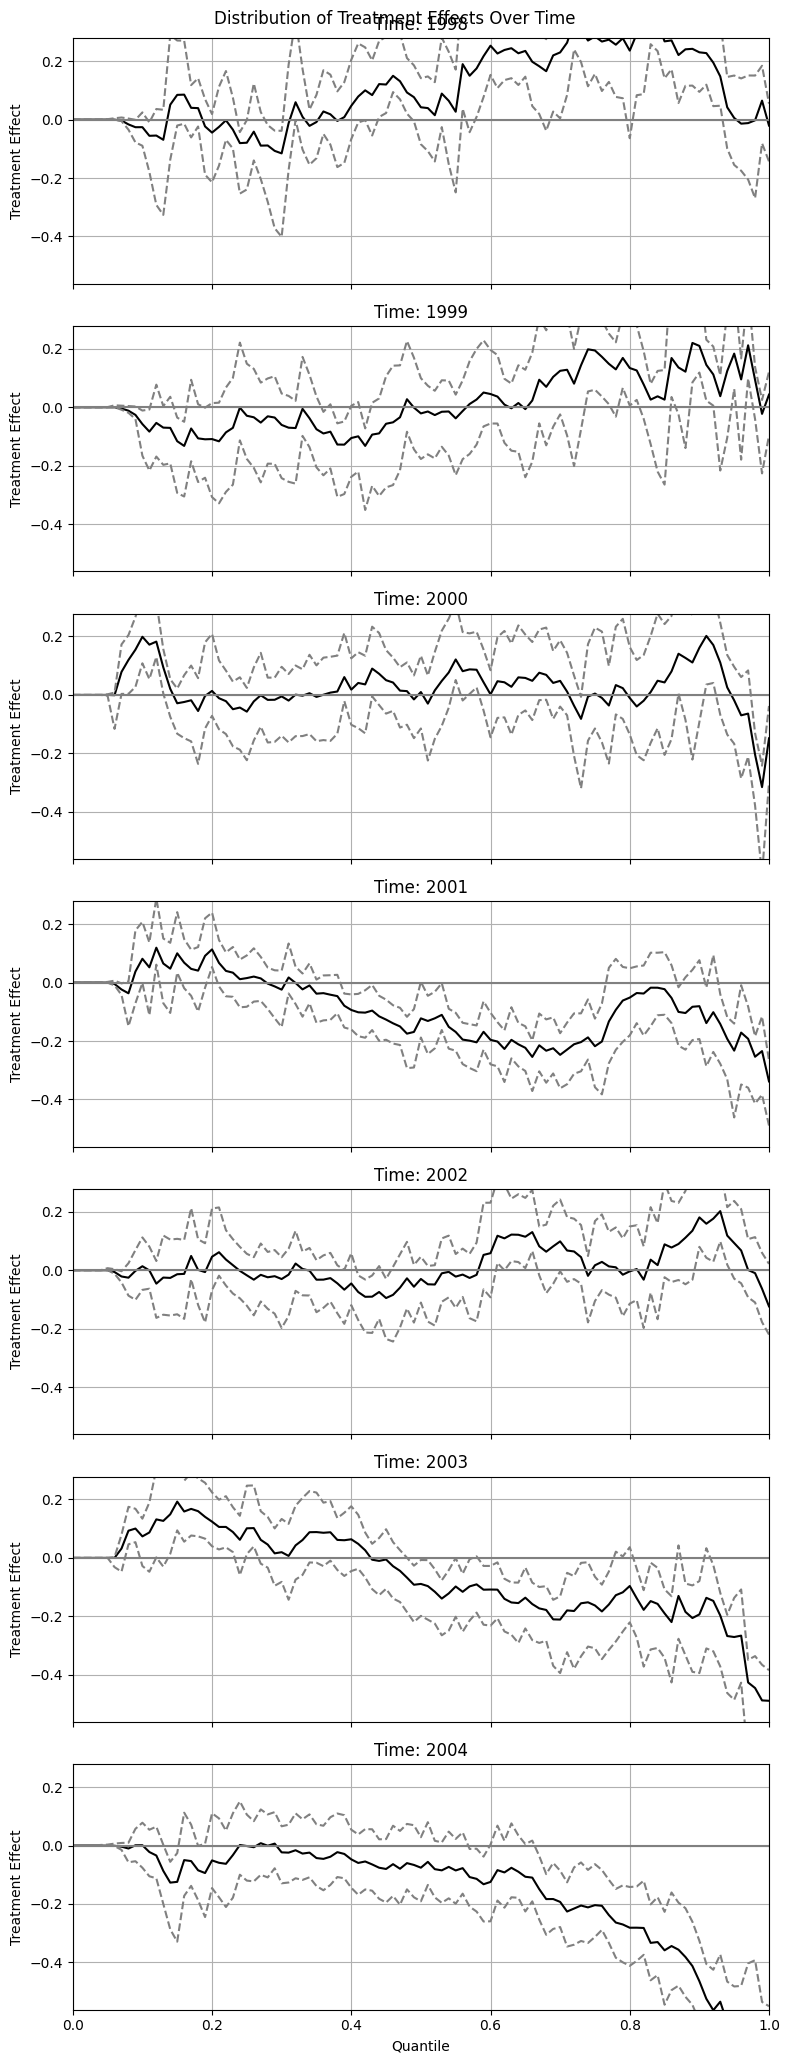

In [16]:
from python.tea import disco_tea
tea_res = disco_tea(result, agg="quantileDiff", graph=True )
print(tea_res.summary())

## Paper replication

### Simulated Data

In [17]:
# Recreation of figure 4 from DiSCo paper
num_controls = 4
sample_size = 1000
seed = 42
synth_df = get_contunious_data(sample_size, num_controls, target_offset=0, dist_control=3, dist_target=4)

fit_synth = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
fit_synth = fit_synth.fit()


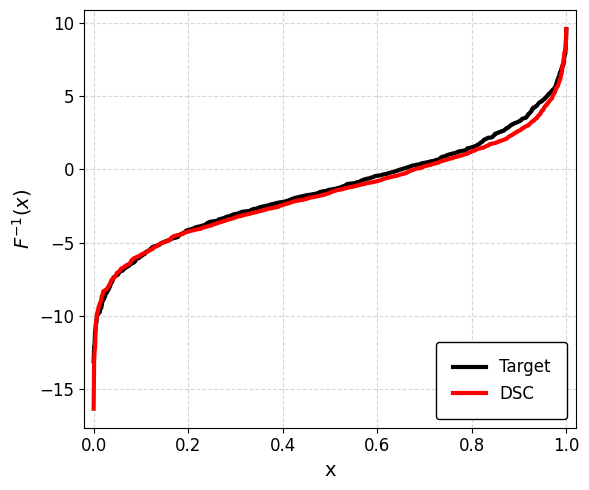

In [18]:
# Get the post-treatment period result to see how it fitted
plot_fit_quantiles(fit_synth, show_controls=False)

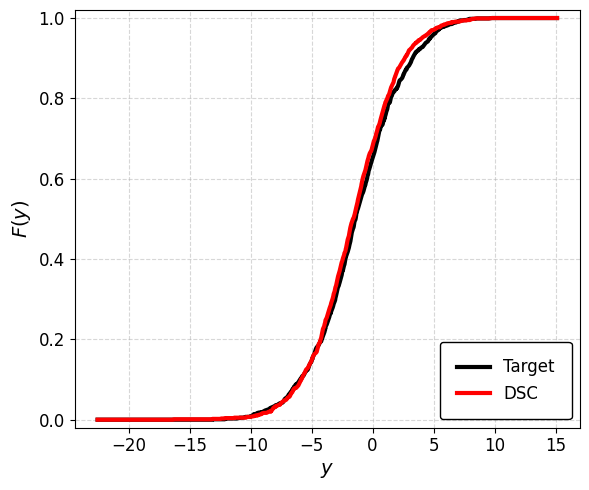

In [19]:
plot_fit_cdf(fit_synth, show_controls=False)

In [20]:
synth_df = get_discrete_data(sample_size, num_controls)

fit_synth_disc = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
)
fit_synth_disc = fit_synth_disc.fit()

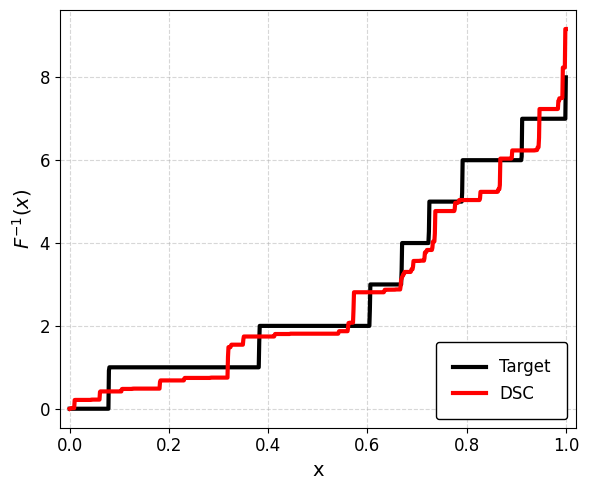

100.0000% der Kontrollen haben ein Gewicht > 1e-4


In [21]:
# Get the post-treatment period result to see how it fitted
period_res = fit_synth_disc.results_periods[2.0]  # The post-treatment period
plot_fit_quantiles(fit_synth_disc, show_controls=False)
weights = period_res.DiSCo.weights
print(f'{(sum(weights > 1e-4)/len(weights))*100:.4f}% der Kontrollen haben ein Gewicht > 1e-4')

### Dube Daten aus 2013

In [22]:
if False:
    dube = pd.read_csv('../dube_full_data/dube_combined.csv')
    dube_2013 = dube[dube['year'] == 2013].copy()
    dube_2013 = dube_2013.sample(frac=1, random_state=42) # Shuffle per state if needed, or globally

    data = []
    for fips, group in dube_2013.groupby('fips'):
        group = group.sample(frac=1, random_state=42) # Shuffle
        mid = len(group) // 2
        
        # Pre-treatment (z.B. Jahr 1)
        pre = group.iloc[:mid].copy()
    pre['year'] = 1
    
    # Post-treatment (z.B. Jahr 2)
    post = group.iloc[mid:].copy()
    post['year'] = 2
    
    data.extend([pre, post])

    dube_synth = pd.concat(data, ignore_index=True)
    dube_synth.head()

In [27]:
if False:    
    fit_dube = DiSCo(
        df=dube_synth,
        id_col='fips',
        time_col='year',
        y_col='adj0contpov',
        id_col_target=26,     # FIPS = 26 (Michigan) als Treatment
        t0=2,                   # Treatment im Jahr 2 (post-treatment)
        M=1000,              # Monte Carlo Draws 
        G=1000,              # Grid Size
        num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
        simplex=True,        # Entspricht den Parametern in der Vignette
        CI=True,
        perm=False,
        seed=None,
        cl=0.99,
    )
    fit_dube = fit_dube.fit()

In [28]:
#plot_fit_quantiles(fit_dube, show_controls=False)

In [29]:
# Super realistische Schwankungen (nahe der vorgegebenen Baseline)
test_df = get_contunious_data(sample_size, num_controls, dim=2, base_corr=0.3, corr_drift=0.1)

print(test_df[test_df['time_col'] == 9999].groupby('id_col').apply(lambda x: np.corrcoef(x['y_col_1'], x['y_col_2'])[0, 1]))
print(np.corrcoef(test_df.loc[test_df['time_col'] == 9999, ['y_col_1', 'y_col_2']].values.T)[0,1])

id_col
0    0.268112
1    0.329507
2    0.215457
3    0.216874
4    0.381376
dtype: float64
0.34359216207205284


In [37]:
test_df['y_col'] = np.array(zip(test_df['y_col_1'], test_df['y_col_2']))
test_df.head()

,id_col,time_col,y_col_1,y_col_2,y_col
0,0,9998,2.054265,7.739823,"(2.054264677757873, 7.739822925205305)"
1,0,9998,3.951314,6.258437,"(3.951314024246601, 6.258437140631018)"
2,0,9998,1.647160,-4.496867,"(1.647160261602377, -4.496866507658421)"
3,0,9998,3.314658,1.866328,"(3.31465753342823, 1.8663283330616385)"
4,0,9998,4.146649,5.691496,"(4.146649035096245, 5.691495997181946)"


In [ ]:
fit_2D = DiSCo(
    df=test_df,
    id_col='id_col',
    time_col='time_col',
    y_col=['y_col_1', 'y_col_2'],
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)


ValueError: could not broadcast input array from shape (1001,1000) into shape (1001,)